# 04 · Evaluation and error analysis (Thadeus)

This notebook checks the frozen model after development. It follows Albert's order: ranking at
monthly capacity, then calibration and errors by cohort and first-gift size. Run `python evals/run_all.py`
from the repository root first to create the data and predictions. All scoring uses the existing
functions in `evals/score.py`, `evals/calibration.py` and `src/model.py`; nothing here tunes or refits a model.

The evaluation is for citizen donors only. “First gift” means the total given in the first month;
“subsequent amount” means all gifts in months M+1 through M+12. A selected donor is a hypothetical
contact, not evidence that anyone was actually called.

**Setup:** load every holdout donor and verify that each has exactly one valid prediction.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(REPO / "evals"), str(REPO / "src")]
import config
import calibration as C
import model as M

df = C.load(REPO / "data/processed/cohorts.parquet", REPO / "data/processed/model_scores.parquet")
print(f"{len(df):,} donors across {df.cohort_month.nunique()} cohort months; {df.y.mean():.1%} returned.")

Holdout citizen donor: 814,971 donors · scored 814,971
814,971 donors across 24 cohort months; 12.6% returned.


## 1 · Does the ranking improve the actual decision?

At 10% monthly capacity, compare the model's dollar score, its return probability, and first-gift
size on the same donors. The objective matters: dollar ranking identifies $120.09 per selected
donor; probability ranking finds more returners but only $107.37. Gift size identifies $116.26.
The dollar-ranked gain is $3.83, or 3.3%. The table also prevents confusing the two lists' small-donor shares.

In [2]:
comparison = C.compare_rankings(df)
display(comparison)
gain = comparison.loc["expected_value", "value_per_contact"] - comparison.loc["first_gift_amount", "value_per_contact"]
print(f"Dollar-ranked gain: ${gain:.2f}/selected donor ({gain / comparison.loc['first_gift_amount', 'value_per_contact']:.1%}).")

,capacity,donors_contacted,repeat_donors_found,precision,recall,value_identified,value_capture_rate,value_per_contact,under_50_share_of_list
ranking,,,,,,,,,
expected_value,0.1,81509,18051,0.221460,0.175723,9788464.74,0.582903,120.090600,0.005509
p_return,0.1,81509,19551,0.239863,0.190326,8751578.71,0.521156,107.369477,0.144156
first_gift_amount,0.1,81509,16085,0.197340,0.156585,9476045.41,0.564298,116.257658,0.000000


Dollar-ranked gain: $3.83/selected donor (3.3%).


## 2 · How much of that gain could be donor-sampling noise?

Use the team's existing paired bootstrap: 30 draws, each containing as many donors as the full test
set, sampled **with replacement**. Rebuild each monthly 10% list in each draw, then subtract gift-size
performance from model performance. Both rules see exactly the same draw. The result is $3.80 ± $0.51;
± is **one standard error**, not a 95% interval. Thirty draws provide a rough noise estimate; this
check does not measure model-training uncertainty, future drift, or transfer to a new nonprofit.

In [3]:
_, paired = M.bootstrap_noise_floor(
    df, {"model_expected_value": df.expected_value.to_numpy(),
         "gift_amount": df.first_gift_amount.to_numpy()},
    config.STEWARDSHIP_CAPACITY)
print(f"Paired bootstrap gain: ${paired[0]:.2f} ± ${paired[1]:.2f} (1 SE, 30 full-size donor resamples).")

Paired bootstrap gain: $3.80 ± $0.51 (1 SE, 30 full-size donor resamples).


## 3 · Do the probabilities mean what they say?

Calibration uses `p_return` even when the contact list is ranked by dollars. Group donors into ten
probability bins and compare predicted with observed return rates. The highest bin predicts 26.6%
and observes 24.2%, so the model is somewhat optimistic at the top. The average absolute bin gap
is 0.73 percentage points. The Brier score improves only 2.3% over predicting the holdout base rate
for everyone; that comparator uses the test base rate and is a diagnostic, not a deployed forecast.

In [4]:
cal, metrics = C.calibration_table(df)
display(cal)
print(f"ECE: {100 * metrics['ece']:.2f} percentage points")
print(f"Brier skill vs constant holdout base rate: {1 - metrics['brier'] / metrics['brier_base_rate']:.2%}")

,donors,predicted,observed,p_low,p_high,gap_pp
bin,,,,,,
0,81500,0.064127,0.075460,0.007334,0.076809,1.133323
1,81495,0.083433,0.087760,0.076810,0.089236,0.432705
2,81498,0.094127,0.098469,0.089236,0.098780,0.434126
3,81497,0.103209,0.105660,0.098780,0.107567,0.245182
4,81496,0.111939,0.111122,0.107567,0.116377,-0.081654
5,81497,0.121110,0.120949,0.116377,0.126050,-0.016073
6,81497,0.131591,0.125759,0.126050,0.137625,-0.583147
7,81497,0.145220,0.137502,0.137625,0.153995,-0.771817
8,81497,0.167639,0.156227,0.153995,0.186611,-1.141245


ECE: 0.73 percentage points
Brier skill vs constant holdout base rate: 2.27%


## 4 · Does performance hold across years?

Build the same dollar-ranked monthly list as the headline, then break its outcomes down by year.
Precision falls from 23.6% to 20.9%, alongside a declining base rate. Dollars per selected donor fall
from $140 to $103, but the gift-size comparison falls from $137 to $99. This supports a gain in both
historical years, not a promise of stable dollar returns in the future. The chart's left panel checks
probabilities; its right panel evaluates the dollar-ranked list.

Model dollar-ranked list


,donors,share_of_donors,base_rate,mean_p,auc,contacted,share_of_list,repeat_donors_found,precision,value_per_contact
cohort_year,,,,,,,,,,
2017,371886,0.456318,0.139500,0.132595,0.597812,37194,0.456318,8770,0.235791,140.235488
2018,443085,0.543682,0.114755,0.125718,0.606190,44315,0.543682,9281,0.209432,103.182805


Gift-size baseline


,donors,share_of_donors,base_rate,mean_p,auc,contacted,share_of_list,repeat_donors_found,precision,value_per_contact
cohort_year,,,,,,,,,,
2017,371886,0.456318,0.139500,0.132595,0.597812,37194,0.456318,7850,0.211056,136.656823
2018,443085,0.543682,0.114755,0.125718,0.606190,44315,0.543682,8235,0.185829,99.136445


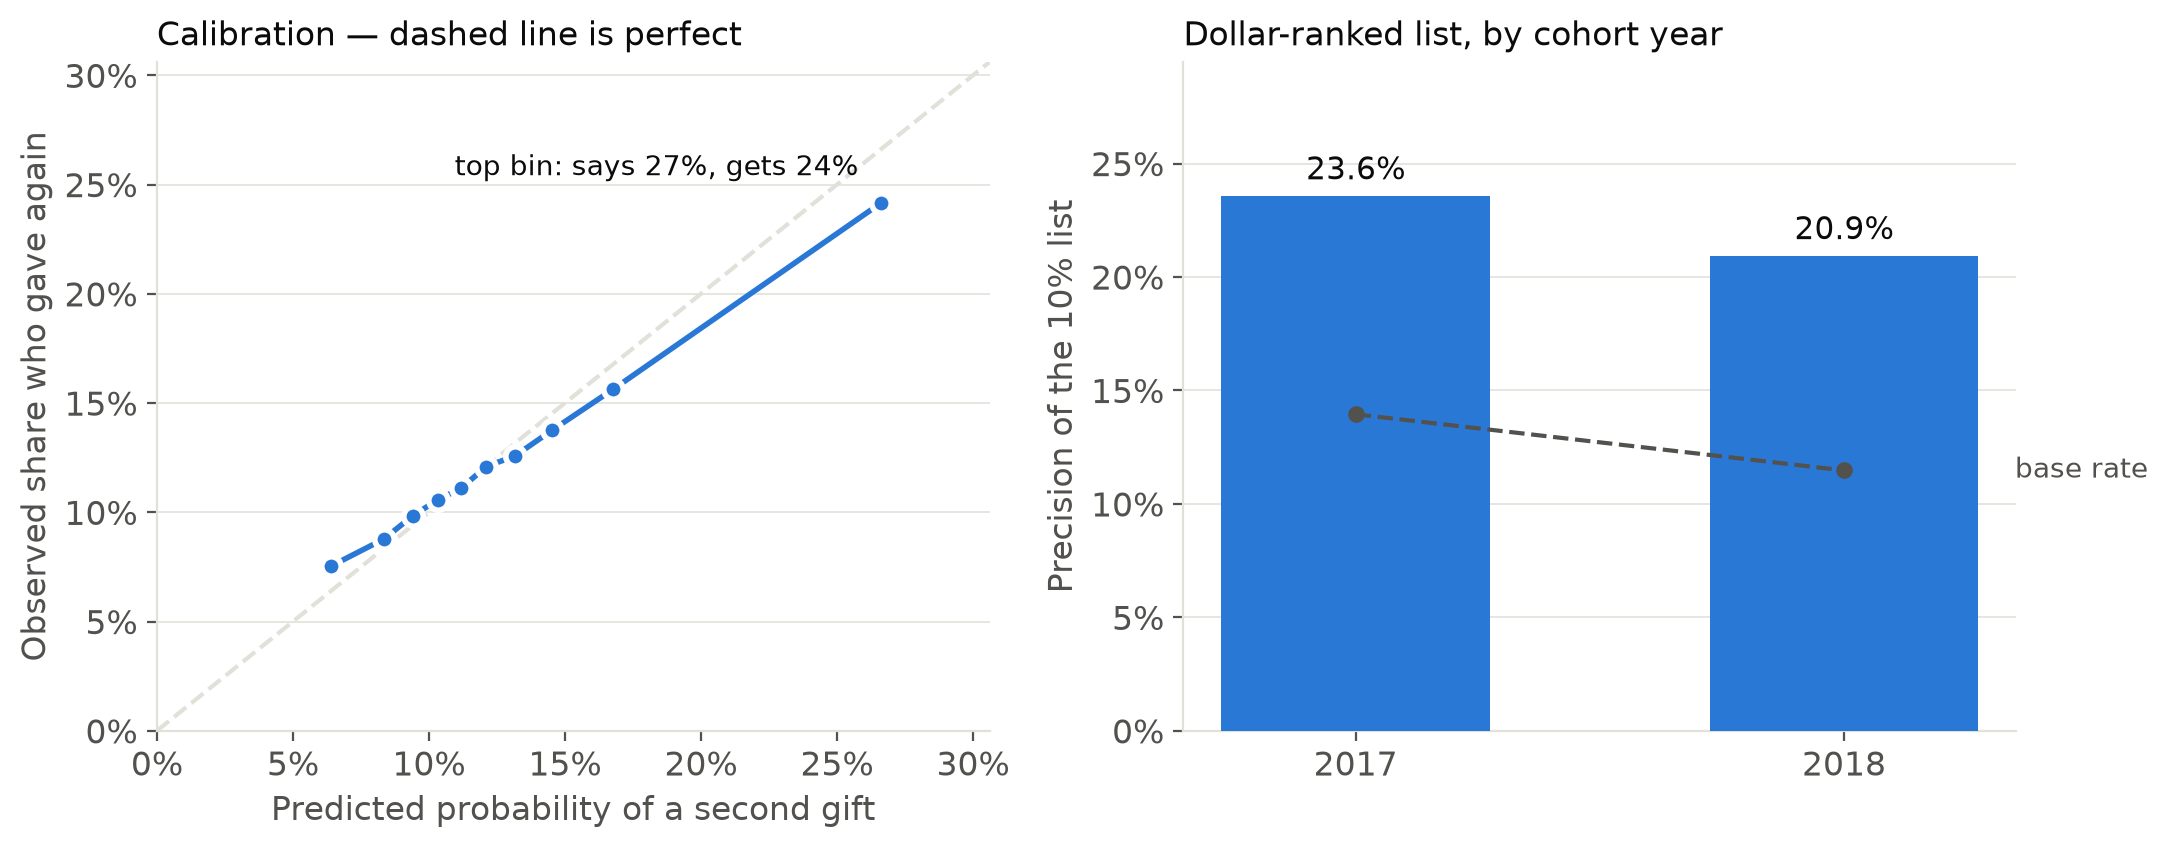

In [5]:
years = C.by_group(df, "cohort_year", ranking="expected_value")
print("Model dollar-ranked list")
display(years)
print("Gift-size baseline")
display(C.by_group(df, "cohort_year", ranking="first_gift_amount"))
chart = C.figure(cal, years, REPO / "docs/slides/assets/slide7_calibration_model", ranking="expected_value")
display(Image(filename=str(chart)))

## 5 · Which donors does the list reach?

Under-$50 donors are 52.4% of the holdout but only **0.55% of the dollar-ranked list**, versus
**14.4% of the probability-ranked list**. Earlier shared wording used 14.4% for the headline list;
this was a ranking mismatch. The few small donors on the dollar list have 42.3% return precision
(449 selected donors). Low coverage is not evidence that the model cannot identify small returners.

Aggregate precision must count returners divided by selected donors. Averaging band percentages
would give a tiny band the same weight as a large one; the shared function now pools the counts.

In [6]:
bands = C.by_size_band(df, ranking="expected_value")
display(bands)
small = bands.loc[["<$10", "$10–24", "$25–49"]]
print(f"Under $50: {small.contacted.sum():,} selected; {small.share_of_list.sum():.2%} of the list; "
      f"{C.pooled_precision(small):.1%} return precision.")
print("For comparison: probability-only list")
display(C.by_size_band(df, ranking="p_return"))

,donors,share_of_donors,base_rate,mean_p,auc,contacted,share_of_list,repeat_donors_found,precision,value_per_contact
band,,,,,,,,,,
<$10,13830,0.016970,0.102025,0.091596,0.558331,0,0.000000,0,NaN,NaN
$10–24,146431,0.179676,0.089339,0.097784,0.587515,25,0.000307,16,0.640000,63.806000
$25–49,267112,0.327756,0.109168,0.112384,0.563215,424,0.005202,174,0.410377,56.361675
$50–99,265054,0.325231,0.139055,0.135986,0.572855,11021,0.135212,2697,0.244715,43.381556
$100–249,98774,0.121199,0.167706,0.174515,0.594501,46640,0.572207,9547,0.204696,54.965888
$250+,23770,0.029167,0.237653,0.257817,0.662527,23399,0.287073,5617,0.240053,287.245399


Under $50: 449 selected; 0.55% of the list; 42.3% return precision.
For comparison: probability-only list


,donors,share_of_donors,base_rate,mean_p,auc,contacted,share_of_list,repeat_donors_found,precision,value_per_contact
band,,,,,,,,,,
<$10,13830,0.016970,0.102025,0.091596,0.558331,334,0.004098,71,0.212575,11.933593
$10–24,146431,0.179676,0.089339,0.097784,0.587515,2956,0.036266,701,0.237145,14.386198
$25–49,267112,0.327756,0.109168,0.112384,0.563215,8460,0.103792,1808,0.213712,18.239512
$50–99,265054,0.325231,0.139055,0.135986,0.572855,26001,0.318995,5955,0.229030,27.481566
$100–249,98774,0.121199,0.167706,0.174515,0.594501,29316,0.359666,6770,0.230932,64.516069
$250+,23770,0.029167,0.237653,0.257817,0.662527,14442,0.177183,4246,0.294004,411.636874


## 6 · Is the result just a handful of unusual accounts?

Repeat the team's existing robustness cut: exclude accounts with 200 or more subsequent gifts.
Seventeen accounts are removed; the dollar-ranked advantage remains $3.71 per selected donor.
This is a sensitivity check, not a new population chosen to improve results.

Also compare mean predicted dollar scores with observed giving. Scores average $10.97 versus
$20.61 observed. The model predicts log amounts, so converting back does not automatically produce
mean expected dollars. A useful ranking is therefore not sufficient validation of a cost threshold.

In [7]:
keep = df.second_gift_count < 200
print(f"Excluded accounts: {(~keep).sum()}")
display(C.compare_rankings(df.loc[keep].reset_index(drop=True)))
print(f"Mean dollar score ${df.expected_value.mean():.2f}; observed mean ${df.second_gift_amount.mean():.2f}.")

Excluded accounts: 17


,capacity,donors_contacted,repeat_donors_found,precision,recall,value_identified,value_capture_rate,value_per_contact,under_50_share_of_list
ranking,,,,,,,,,
expected_value,0.1,81508,18040,0.221328,0.175645,8519596.22,0.551372,104.524663,0.005496
p_return,0.1,81508,19540,0.239731,0.190250,7450837.08,0.482204,91.412341,0.144145
first_gift_amount,0.1,81508,16077,0.197244,0.156533,8217053.83,0.531792,100.812851,0.000000


Mean dollar score $10.97; observed mean $20.61.


## Interpretation for slides 7 and 9

The model modestly improves a strong gift-size baseline, and that improvement survives the
reported donor resampling and unusual-account check. Its dollar-ranked list still concentrates
on large gifts. Probability estimates are somewhat optimistic at the top, and the historical
dollar level changes between years.

We have **not** measured the additional donations caused by outreach. Historical giving minus
hypothetical contact costs is not outreach profit. The $25 cost needs Malorie's evidence; the
amount score needs mean-dollar calibration before literal cost thresholds. A randomized outreach
pilot and local validation are the next steps before deployment.

The thank-you-packet flag is excluded because its timing is ambiguous. Transfer from 2017–18
DonorsChoose cohorts to today's donors or another nonprofit remains untested. First-month
features imply making the decision after that month closes; this is not a day-of-first-gift model.
The retrospective split also permits training outcome windows to extend into 2017; it is not a
fully simulated deployment at the start of 2017.

**AI use:** Codex assisted with this review, code corrections, tests, notebook and slide drafts.
Verification: full raw-data reproduction, fixed-prediction comparisons and regression tests in
`tests/test_calibration.py`. Thadeus reviews the interpretation and presents it; team review is pending.